In [1]:
import numpy as np
import matplotlib.pyplot as plt

- K means and two gaussian distributions

In [2]:
gauss_data = "/home/tadej/Desktop/STUDIJ/mag-2.letnik/PSUF/PSUF6/data/gauss.npy"
data = np.load(gauss_data, allow_pickle=True)
print("Oblika podatkov:", data.shape)

Oblika podatkov: (400, 2)


In [3]:
def k_means(data, K=2, max_iter=100, tol=1e-6, random_state=42):
    rng = np.random.default_rng(random_state)

    initial_indices = rng.choice(len(data), size=K, replace=False)
    centroids = data[initial_indices].copy()

    initial_centroids = centroids.copy()

    for iteration in range(max_iter):

        distances = np.linalg.norm(
            data[:, None, :] - centroids[None, :, :],
            axis=2
        )

        labels = np.argmin(distances, axis=1)

        new_centroids = np.empty_like(centroids)

        for k in range(K):
            cluster_points = data[labels == k]

            if len(cluster_points) == 0:
                new_centroids[k] = data[rng.integers(len(data))]
            else:
                new_centroids[k] = np.mean(cluster_points, axis=0)

        centroid_shift = np.linalg.norm(new_centroids - centroids)
        centroids = new_centroids

        if centroid_shift < tol:
            break

    # Končne oznake
    distances = np.linalg.norm(
        data[:, None, :] - centroids[None, :, :],
        axis=2
    )
    labels = np.argmin(distances, axis=1)

    return labels, initial_centroids, centroids, iteration + 1

In [4]:
labels, initial_centroids, centroids, n_iter = k_means(
    data,
    K=2,
    random_state=42
)

# 424 je zanimiva

print(f"Konvergenca po {n_iter} iteracijah.")
print("Končni centroidi:")
print(centroids)

Konvergenca po 4 iteracijah.
Končni centroidi:
[[-1.45467308 -0.49259767]
 [ 1.49244299  0.79561583]]


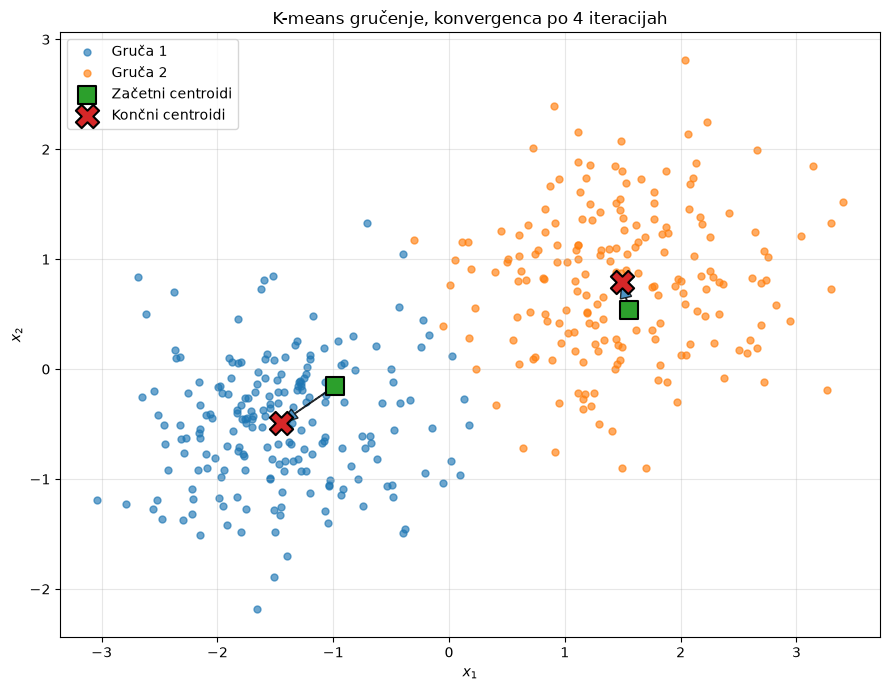

In [5]:
plt.figure(figsize=(9, 7))

for k in range(2):
    cluster_points = data[labels == k]

    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        s=25,
        alpha=0.65,
        label=f"Gruča {k + 1}"
    )

# Začetni centroidi
plt.scatter(
    initial_centroids[:, 0],
    initial_centroids[:, 1],
    marker="s",
    s=160,
    edgecolors="black",
    linewidths=1.5,
    label="Začetni centroidi",
    zorder=5
)

# Končni centroidi
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=280,
    edgecolors="black",
    linewidths=1.5,
    label="Končni centroidi",
    zorder=6
)

# Puščica od začetnega do končnega centroida
for k in range(2):
    dx = centroids[k, 0] - initial_centroids[k, 0]
    dy = centroids[k, 1] - initial_centroids[k, 1]

    plt.arrow(
        initial_centroids[k, 0],
        initial_centroids[k, 1],
        dx,
        dy,
        width=0.005,
        head_width=0.10,
        head_length=0.15,
        length_includes_head=True,
        alpha=0.8,
        zorder=4
    )

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title(f"K-means gručenje, konvergenca po {n_iter} iteracijah")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- Različni začetni pogoji

In [6]:
def k_means(data, K=2, max_iter=100, tol=1e-6, random_state=None):
    rng = np.random.default_rng(random_state)

    # Naključno izberemo K podatkovnih točk kot začetne centroide
    initial_indices = rng.choice(len(data), size=K, replace=False)
    centroids = data[initial_indices].copy()

    initial_centroids = centroids.copy()

    for iteration in range(max_iter):

        # Kvadrati evklidskih razdalj:
        # oblika matrike je (N, K)
        squared_distances = np.sum(
            (data[:, None, :] - centroids[None, :, :])**2,
            axis=2
        )

        # Vsaki točki pripišemo najbližji centroid
        labels = np.argmin(squared_distances, axis=1)

        new_centroids = np.empty_like(centroids)

        for k in range(K):
            cluster_points = data[labels == k]

            if len(cluster_points) == 0:
                # Če je gruča prazna, centroid ponovno inicializiramo
                new_centroids[k] = data[rng.integers(len(data))]
            else:
                new_centroids[k] = np.mean(cluster_points, axis=0)

        # Največji premik kateregakoli centroida
        shifts = np.linalg.norm(new_centroids - centroids, axis=1)

        centroids = new_centroids

        if np.max(shifts) < tol:
            break

    # Končne oznake in razdalje
    squared_distances = np.sum(
        (data[:, None, :] - centroids[None, :, :])**2,
        axis=2
    )

    labels = np.argmin(squared_distances, axis=1)

    # Kriterijska funkcija K-means:
    # za vsako točko vzamemo razdaljo do njenega centroida
    inertia = np.sum(
        squared_distances[np.arange(len(data)), labels]
    )

    return {
        "labels": labels,
        "initial_centroids": initial_centroids,
        "centroids": centroids,
        "inertia": inertia,
        "n_iter": iteration + 1
    }

In [7]:
n_runs = 20
results = []

for seed in range(n_runs):
    result = k_means(
        data,
        K=2,
        random_state=seed
    )

    result["seed"] = seed
    results.append(result)

In [8]:
print(
    f"{'Seed':>4}  "
    f"{'mu1_x':>9} {'mu1_y':>9}  "
    f"{'mu2_x':>9} {'mu2_y':>9}  "
    f"{'J':>12}  "
    f"{'iter':>5}"
)

for result in results:
    ordered_centroids = result["centroids"][
        np.argsort(result["centroids"][:, 0])
    ]

    print(
        f"{result['seed']:4d}  "
        f"{ordered_centroids[0, 0]:9.4f} "
        f"{ordered_centroids[0, 1]:9.4f}  "
        f"{ordered_centroids[1, 0]:9.4f} "
        f"{ordered_centroids[1, 1]:9.4f}  "
        f"{result['inertia']:12.4f}  "
        f"{result['n_iter']:5d}"
    )

Seed      mu1_x     mu1_y      mu2_x     mu2_y             J   iter
   0    -1.4620   -0.4956     1.4850    0.7922      342.5316      5
   1    -1.4620   -0.4956     1.4850    0.7922      342.5316      5
   2    -1.4620   -0.4956     1.4850    0.7922      342.5316      4
   3    -1.4620   -0.4956     1.4850    0.7922      342.5316      5
   4    -1.4547   -0.4926     1.4924    0.7956      342.5235      4
   5    -1.4547   -0.4926     1.4924    0.7956      342.5235      4
   6    -1.4620   -0.4956     1.4850    0.7922      342.5316      5
   7    -1.4620   -0.4956     1.4850    0.7922      342.5316      6
   8    -1.4620   -0.4956     1.4850    0.7922      342.5316      5
   9    -1.4620   -0.4956     1.4850    0.7922      342.5316      6
  10    -1.4620   -0.4956     1.4850    0.7922      342.5316      4
  11    -1.4620   -0.4956     1.4850    0.7922      342.5316      4
  12    -1.4620   -0.4956     1.4850    0.7922      342.5316      6
  13    -1.4620   -0.4956     1.4850    0.7922  

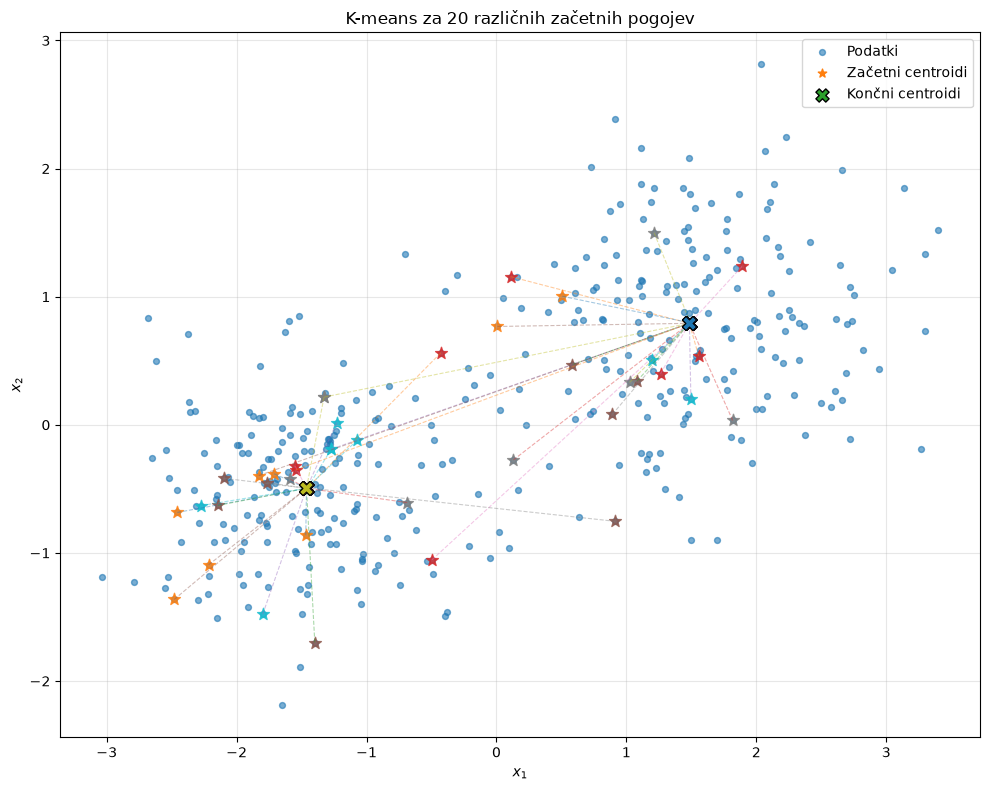

In [9]:
plt.figure(figsize=(10, 8))

# Vsi podatki
plt.scatter(
    data[:, 0],
    data[:, 1],
    s=18,
    alpha=0.6,
    label="Podatki"
)

for run_number, result in enumerate(results):

    initial = result["initial_centroids"]
    final = result["centroids"]

    for k in range(2):

        # Povezava od začetnega do končnega položaja
        plt.plot(
            [initial[k, 0], final[k, 0]],
            [initial[k, 1], final[k, 1]],
            linestyle="--",
            linewidth=0.8,
            alpha=0.4
        )

        # Začetni centroid
        plt.scatter(
            initial[k, 0],
            initial[k, 1],
            marker="*",
            s=80,
            alpha=0.8
        )

        # Končni centroid
        plt.scatter(
            final[k, 0],
            final[k, 1],
            marker="X",
            s=100,
            edgecolors="black",
            linewidths=0.7,
            zorder=5
        )

plt.scatter([], [], marker="*", s=40, label="Začetni centroidi")
plt.scatter(
    [], [],
    marker="X",
    s=90,
    edgecolors="black",
    label="Končni centroidi"
)
plt.legend()

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title(f"K-means za {n_runs} različnih začetnih pogojev")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# Urejeni končni centroidi in povprečne razdalje za vsak zagon
ordered_centroids = []
mean_distances = []

for result in results:
    centroids = result["centroids"]
    labels = result["labels"]

    # Levo gručo vedno označimo kot centroid 1,
    # desno pa kot centroid 2
    order = np.argsort(centroids[:, 0])
    sorted_centroids = centroids[order]

    ordered_centroids.append(sorted_centroids)

    # Razdalja vsake točke do njenega pripadajočega centroida
    point_distances = np.linalg.norm(
        data - centroids[labels],
        axis=1
    )

    mean_distances.append(np.mean(point_distances))


ordered_centroids = np.array(ordered_centroids)
mean_distances = np.array(mean_distances)

# Koordinate centroidov skozi vse zagone
x_centroid_1 = ordered_centroids[:, 0, 0]
y_centroid_1 = ordered_centroids[:, 0, 1]

x_centroid_2 = ordered_centroids[:, 1, 0]
y_centroid_2 = ordered_centroids[:, 1, 1]